This example shows how to use `pymsis` to compute elemental abundances for McMurdo Station, Antarctica.
It contains some examples from the `pymsis` documentation to verify it's working.

In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from pymsis import msis

from adetsim.atmosphere import compute_lookup_table, plot_abundances, style_file

# Using pre-made tools

This computes a lookup table containing atmospheric data for McMurdo Station, Antarctica and plots the abundances vs. altitude.

removed Anomalous Oden
removed NOden
  total mass density           N2den          ...    Temperature     altitude
       g / cm3                1 / cm3         ...         K             km   
---------------------- ---------------------- ... ------------------ --------
 0.0013359237927943468 2.1701593161042756e+19 ... 261.31146240234375      0.0
 0.0011882587568834424 1.9302828225142456e+19 ...  257.4674987792969      1.0
  0.001058763824403286 1.7199231583765135e+19 ...  252.6787872314453      2.0
 0.0009433234226889908 1.5323945233360617e+19 ... 247.32630920410156      3.0
 0.0008390956209041178 1.3630802879701844e+19 ... 241.75013732910156      4.0
 0.0007441749912686646 1.2088851071443665e+19 ... 236.24143981933594      5.0
 0.0006573236314579844 1.0677981939937313e+19 ...  231.0440673828125      6.0
 0.0005777694168500602  9.385653356044747e+18 ... 226.36386108398438      7.0
 0.0005050402251072228  8.204194576894788e+18 ... 222.37493896484375      8.0
                   ...     

<Axes: title={'center': 'Atmospheric Abundances on 2023-12-01T00:00, -77.84 deg, 166.67 deg'}, xlabel='Altitude (km)', ylabel='Abundance'>

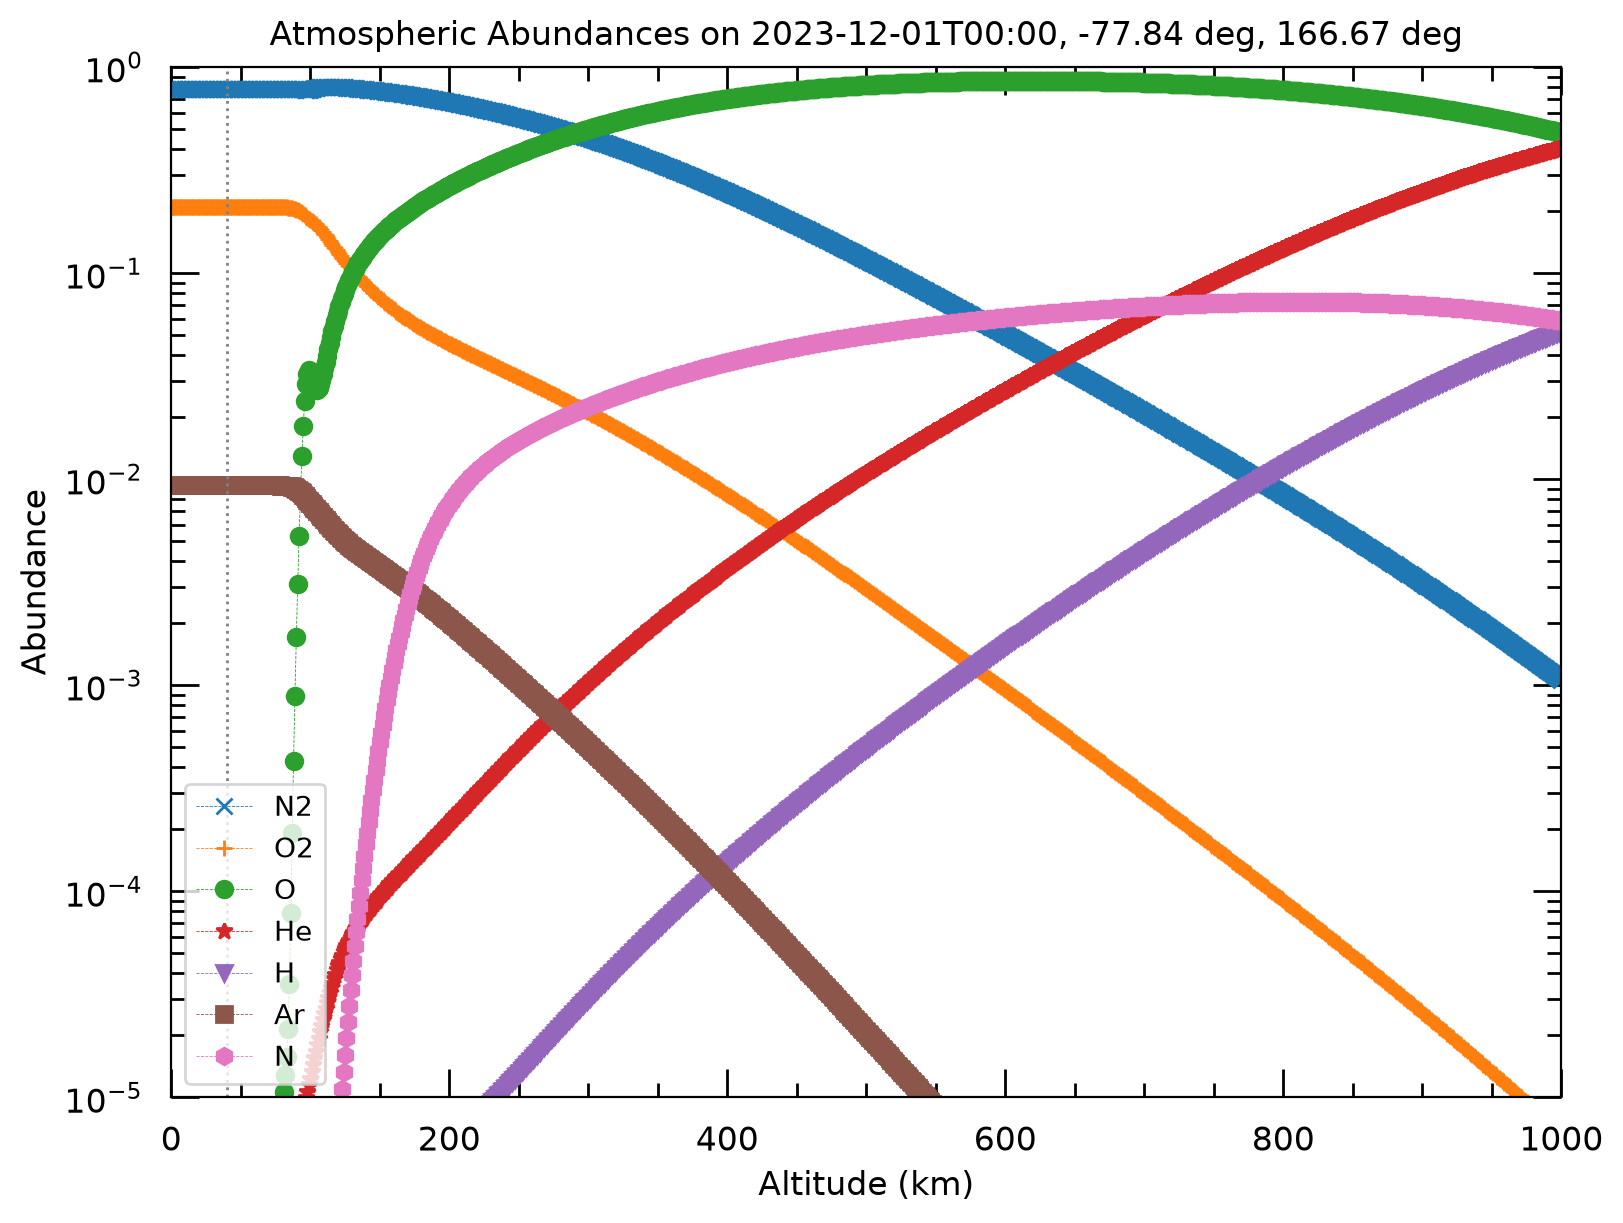

In [2]:
mcmurdo_table = compute_lookup_table(
    np.datetime64("2023-12-01T00:00"),
    -77.84 * u.degree,
    166.67 * u.degree,
    0 * u.km,
    1000 * u.km,
    1 * u.km,
)
print(mcmurdo_table)
plot_abundances(mcmurdo_table)

# Adaptation of online example

Plots the difference between noon and midnight.
Uses parameters corresponding to McMurdo Station, Antarctica.

<class 'numpy.ndarray'> (1, 1, 1, 1001, 11)
[[[[[1.3370657e+00 2.1720146e+25 5.8244176e+24 ...           nan
               nan 2.6108853e+02]
    [1.2232265e+00 1.9870870e+25 5.3285202e+24 ...           nan
               nan 2.5853476e+02]
    [1.1210322e+00 1.8210761e+25 4.8833501e+24 ...           nan
               nan 2.5527707e+02]
    ...
    [6.7305272e-14 9.5049245e+10 1.4111590e+09 ... 6.6395034e+10
     1.1201248e+08 1.5138307e+03]
    [6.6793901e-14 9.3808452e+10 1.3901363e+09 ... 6.6223407e+10
     1.1044717e+08 1.5138315e+03]
    [6.6286434e-14 9.2584190e+10 1.3694323e+09 ... 6.6052223e+10
     1.0890372e+08 1.5138324e+03]]]]]


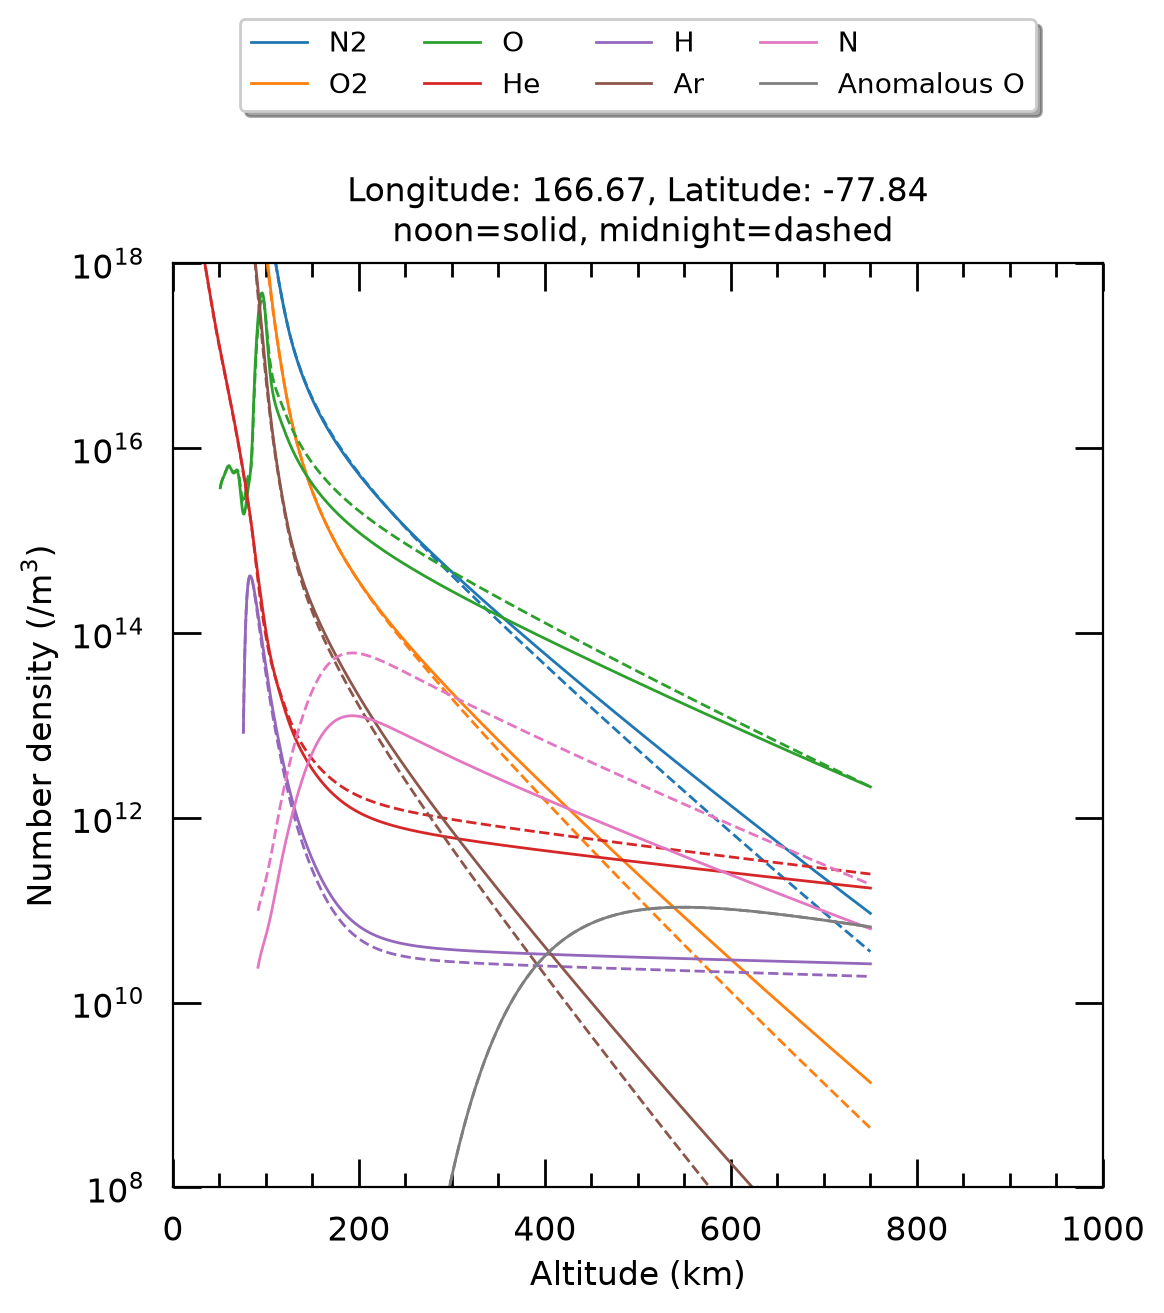

In [3]:
lon = 166.67
lat = -77.84
alts = np.linspace(0, 750, 1001)
# f107 = 150
# f107a = 150
ap = 7
aps = [[ap] * 7]

date = np.datetime64("2023-12-01T00:00")
output_midnight = msis.run(date, lon, lat, alts)
date = np.datetime64("2023-12-01T12:00")
output_noon = msis.run(date, lon, lat, alts)

print(output_noon.__class__, output_noon.shape)
print(output_noon)

#  output is now of the shape (1, 1, 1, 1000, 11)
# Get rid of the single dimensions
output_midnight = np.squeeze(output_midnight)
output_noon = np.squeeze(output_noon)

variables = [
    "Total mass density",
    "N2",
    "O2",
    "O",
    "He",
    "H",
    "Ar",
    "N",
    "Anomalous O",
    "NO",
    "Temperature",
]

with plt.style.context(style_file):
    _, ax = plt.subplots()
    for i, label in enumerate(variables):
        if label in ("NO", "Total mass density", "Temperature"):
            # There is currently no NO data, also ignore non-number densities
            continue
        (line,) = ax.plot(alts, output_midnight[:, i], linestyle="--")
        ax.plot(alts, output_noon[:, i], c=line.get_color(), label=label)

    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.15),
        fancybox=True,
        shadow=True,
        ncol=4,
    )

    ax.set_title(f"Longitude: {lon}, Latitude: {lat}\n noon=solid, midnight=dashed")
    ax.set_yscale("log")
    ax.set_ylim(1e8, 1e18)
    ax.set_xlim(0, 1000)
    ax.set_ylabel("Number density (/m$^3$)")
    ax.set_xlabel("Altitude (km)")

    plt.show()